In [1]:
import os

import sys
import numpy as np
import matplotlib.pyplot as plt

from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data, timeseries_train_test_split

from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
import seaborn as sns

%reload_ext autoreload
%autoreload 2

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-22 11:36:20,824	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
!pwd

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/monkey


## Load data

For the monkey dataset, use the following Google Drive link to download the folder, and save it in `data/` as `data/monkey_reaching_preload_smth_40/active_all.jl`:

https://drive.google.com/drive/folders/1XWEyTyfgYnz5UQCmnU9gRRuFBwRtyrWF?usp=sharing


In [3]:

import numpy as np

x = np.load('../data/raw/monkey/neural.npy')
# b_continuous = np.load('../data/raw/monkey/behaviour_position.npy')
b = np.load('../data/raw/monkey/reach_direction_discrete.npy')


In [4]:
# rearranging into trials
b_trials = b.reshape(b.shape[0]//600, -1) # b_trials shares memory with b and will be altered in place
print(b_trials.var(axis=1))
print(b_trials)
b_trials[:,:20] = 8
b_trials[:,-20:] = 9
b

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [6 6 6 ... 6 6 6]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


array([8, 8, 8, ..., 9, 9, 9])

<IPython.core.display.Javascript object>


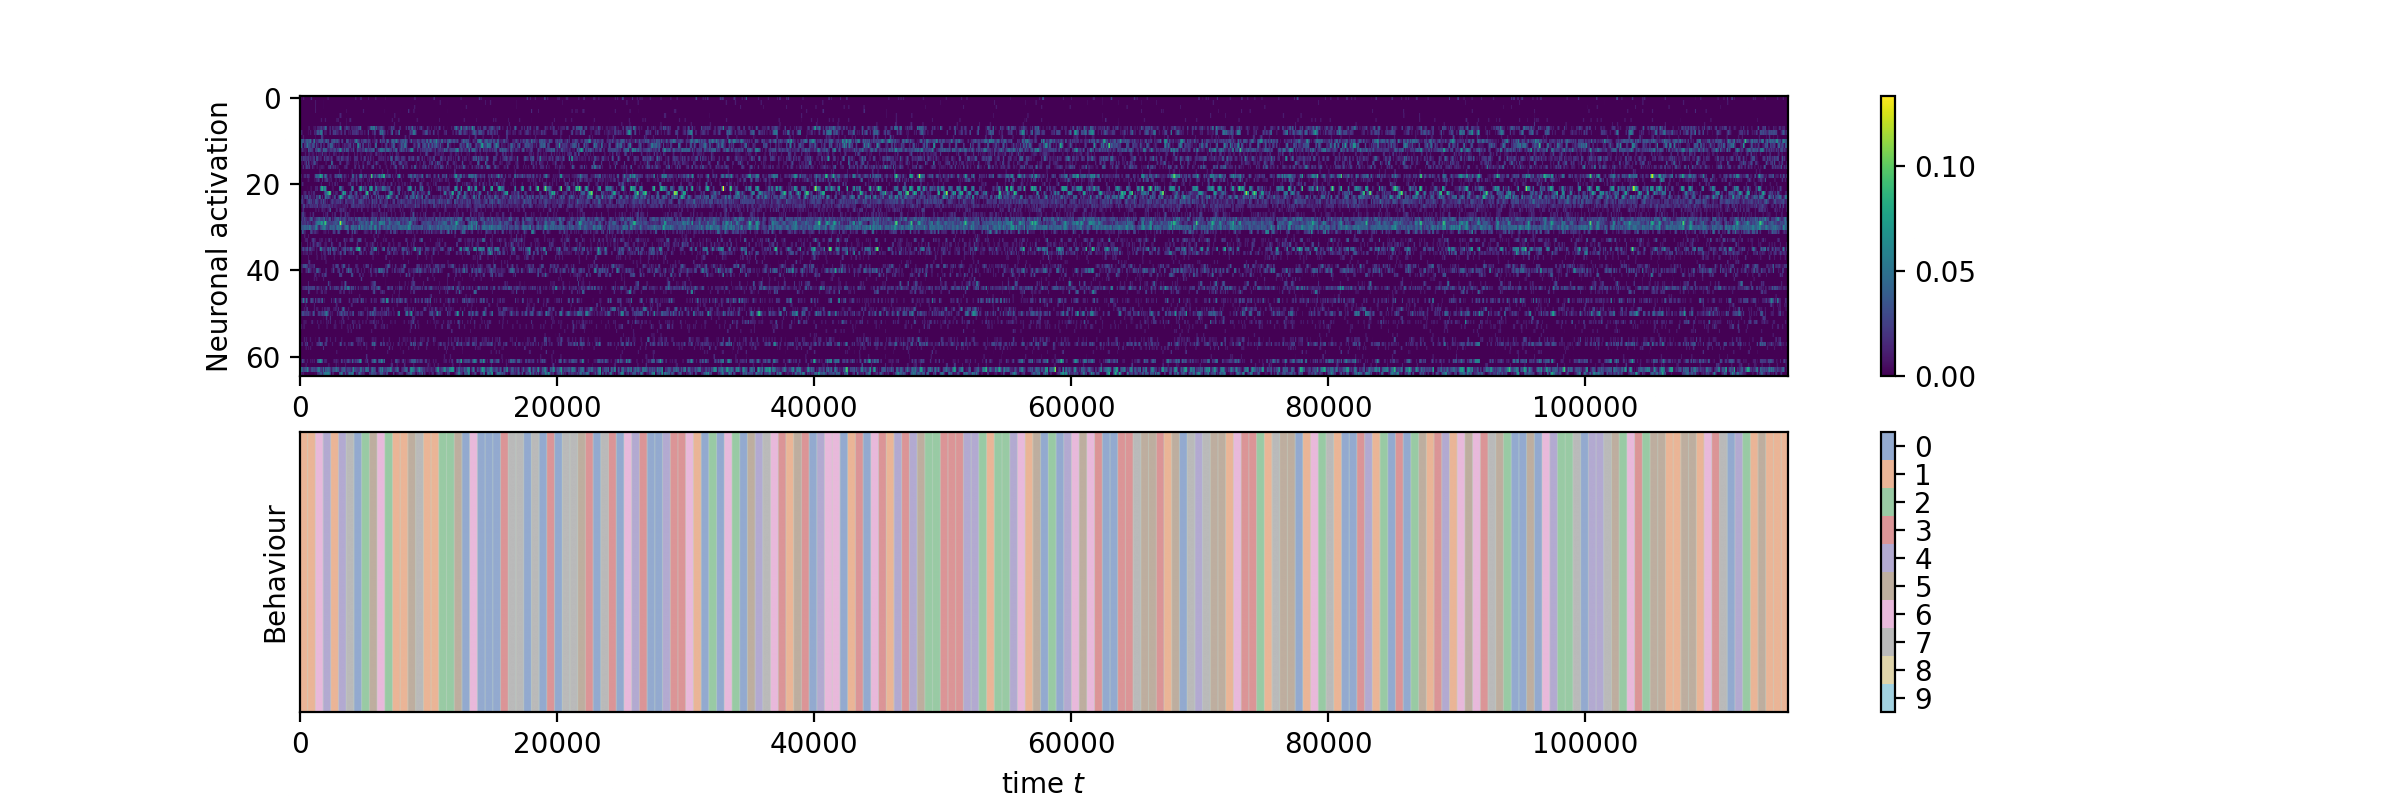

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [5]:
%matplotlib notebook

plotting_neuronal_behavioural(x, b, b_names=np.unique(b))

## BunDLe-Net

In [ ]:
x_, b_ = prep_data(x, b, win=50)
x_train, x_test, b_train, b_test = timeseries_train_test_split(x_, b_)

### Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=len(np.unique(b_train)), input_shape=x_train.shape)

train_history, test_history = train_model(
        x_train,
        b_train,
        model,
        b_type='discrete',
        gamma=0.9,
        learning_rate=0.001,
        n_epochs=500,
        initialisation=None,
        validation_data=(x_test, b_test),
    )

Loss [Markov, Behaviour, Total]: [0.0051 0.002  0.0071]:  21%|█    | 105/500 [09:00<31:00,  4.71s/it]

In [ ]:
# Training losses vs epochs
plt.figure()
for i, label in  enumerate(["$\mathcal{L}_{{Markov}}$", "$\mathcal{L}_{{Behavior}}$","Total loss $\mathcal{L}$" ]):
    plt.semilogy(train_history[:,i], label=label)

plt.legend()
plt.show()

## Projecting into latent space

In [22]:
# projecting into latent space
from ncmcm.bundlenet.bundlenet import project_into_latent_space
y0_tr = project_into_latent_space(x_train[:, 0], model)
y1_tr = project_into_latent_space(x_train[:, 1], model)
y0_tst = project_into_latent_space(x_test[:, 0], model)
y1_tst = project_into_latent_space(x_test[:, 1], model)
y0_ = project_into_latent_space(x_[:,0], model)
y1_ = project_into_latent_space(x_[:,1], model)

np.save('y0_.npy', y0_)
np.save('y1_.npy', y1_)
np.save('b_.npy', b_)

In [23]:
y0_ = np.load('y0_.npy')
y1_ = np.load('y1_.npy')
b_ = np.load('b_.npy')

## Visualising embedding

<IPython.core.display.Javascript object>


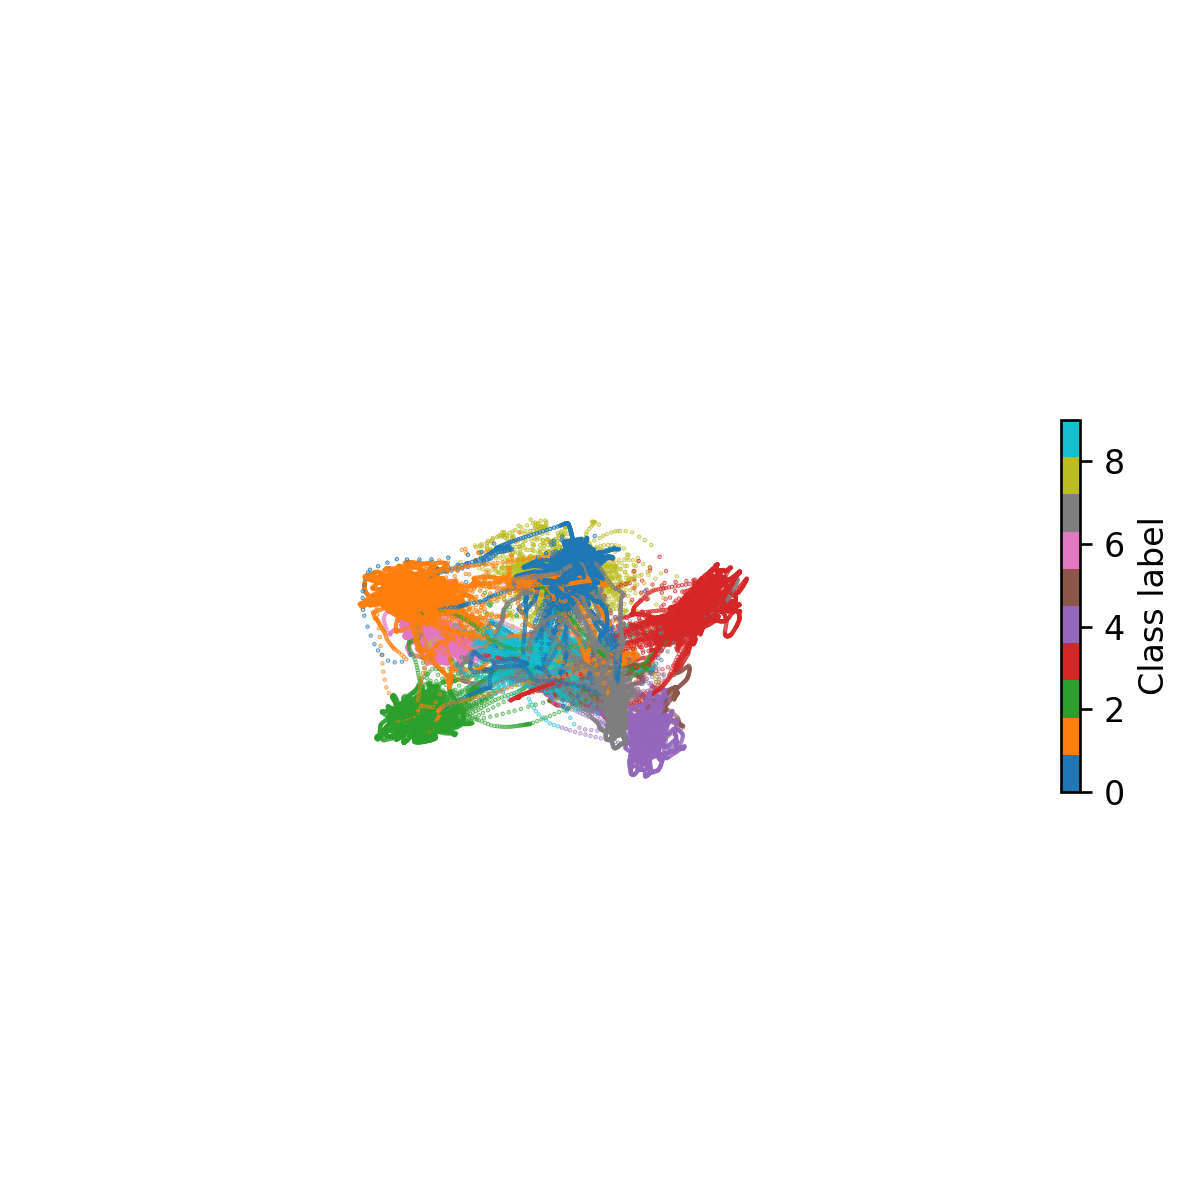

In [24]:
%matplotlib notebook
def plot_embedding(Y0_, B_, title=None, **kwargs):
    elev, azim, roll = 27,10,0
    fig = plt.figure(figsize=(5, 5))
    plt.suptitle(title,
                 fontsize=20)
    ax = plt.subplot(projection = '3d')
    ax.view_init(**kwargs)
    scatterplot = ax.scatter(Y0_[:, 0],
                   Y0_[:, 1],
                   Y0_[:, 2],
                   c=B_,
                   cmap='tab10',
                   s=0.1
                  )
    cbar = fig.colorbar(scatterplot, ax=ax, fraction=0.02, pad=0.1)
    cbar.set_label('Class label', fontsize=10)
    ax.axis('off')
    plt.show()

plot_embedding(y0_, b_, elev=27, azim=10)

# decoding analysis with continuous behaviour

In [27]:

import numpy as np

x = np.load('../data/raw/monkey/neural.npy')
b = np.load('../data/raw/monkey/behaviour_position.npy') # loading continuous behaviour

x_, b_ = prep_data(x, b, win=50)
_, _, b_train, b_test = timeseries_train_test_split(x_, b_)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit linear regressor
reg = LinearRegression()
reg.fit(y0_tr, b_train)

# Predict
b_pred = reg.predict(y0_tst)

# Evaluate
mse = mean_squared_error(b_test, b_pred)
r2_model = r2_score(b_test, b_pred)

print(f"MSE: {mse:.4f}")
print(f"R² score: {r2_model:.4f}")


MSE: 17.9934
R² score: 0.2168


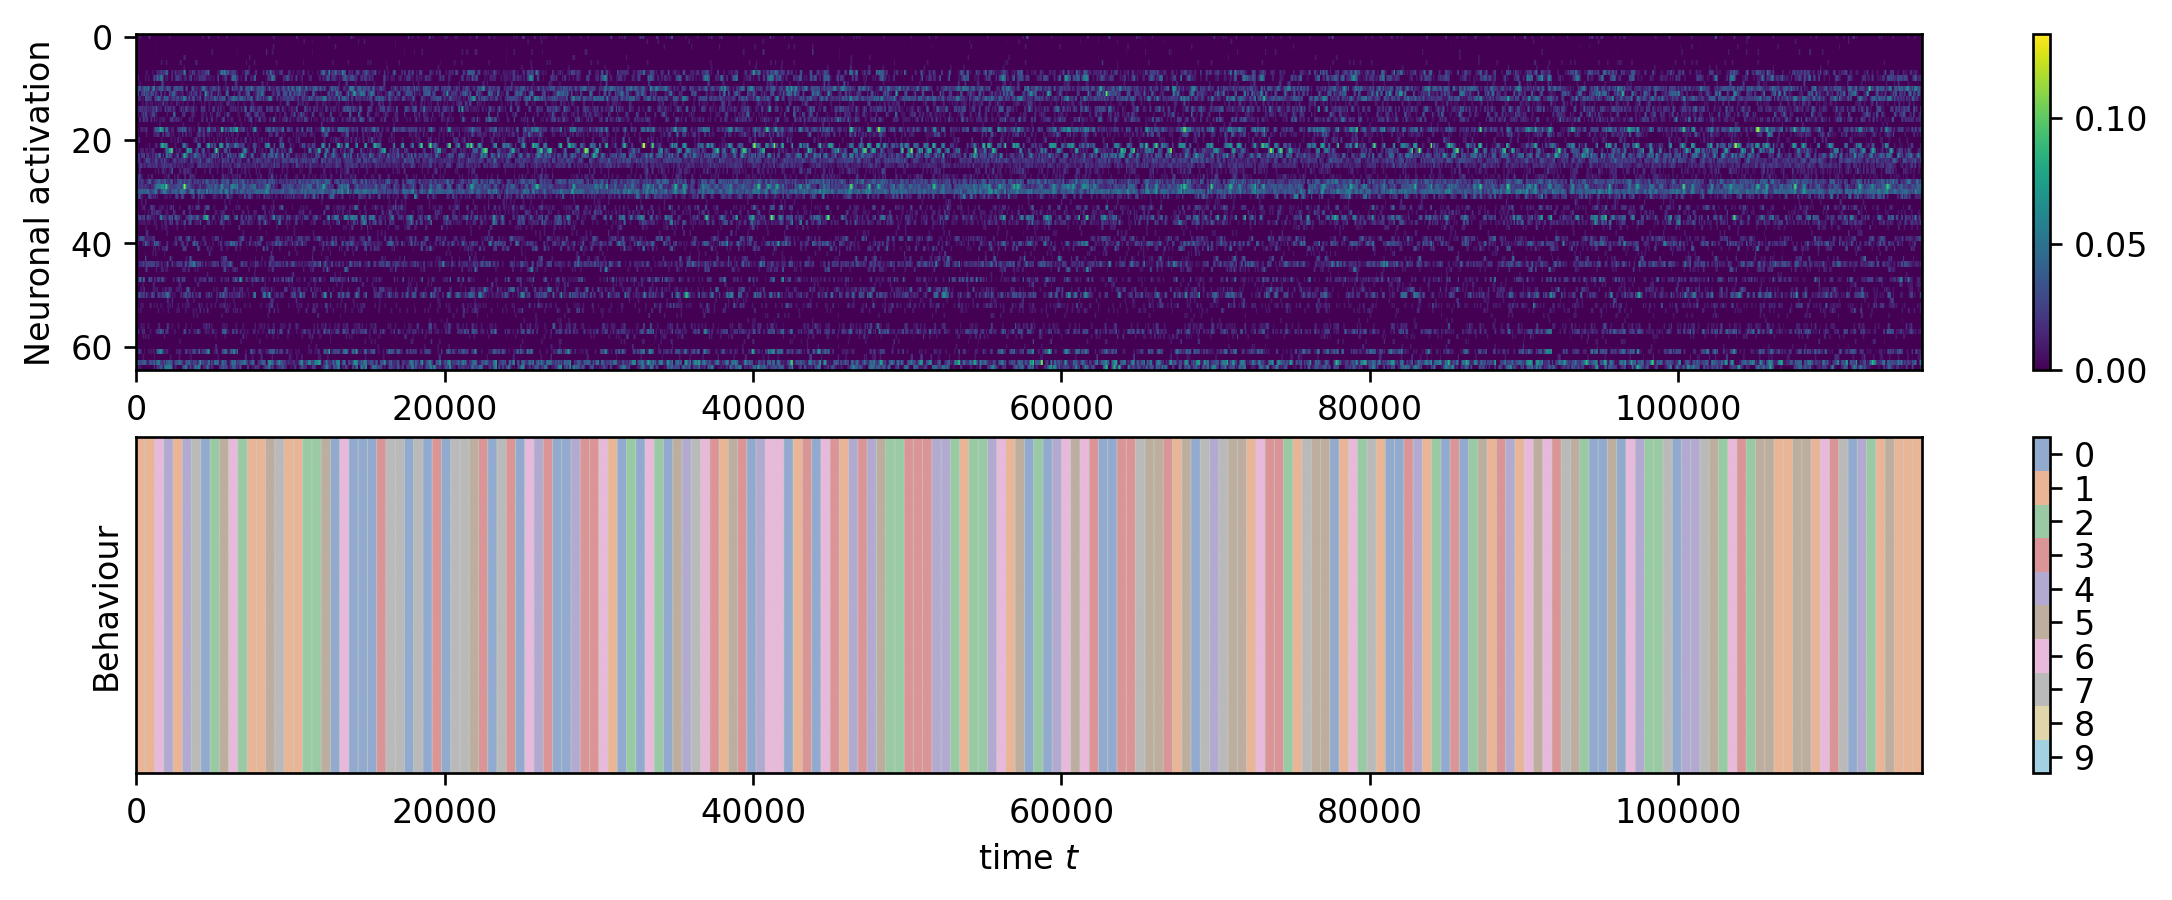

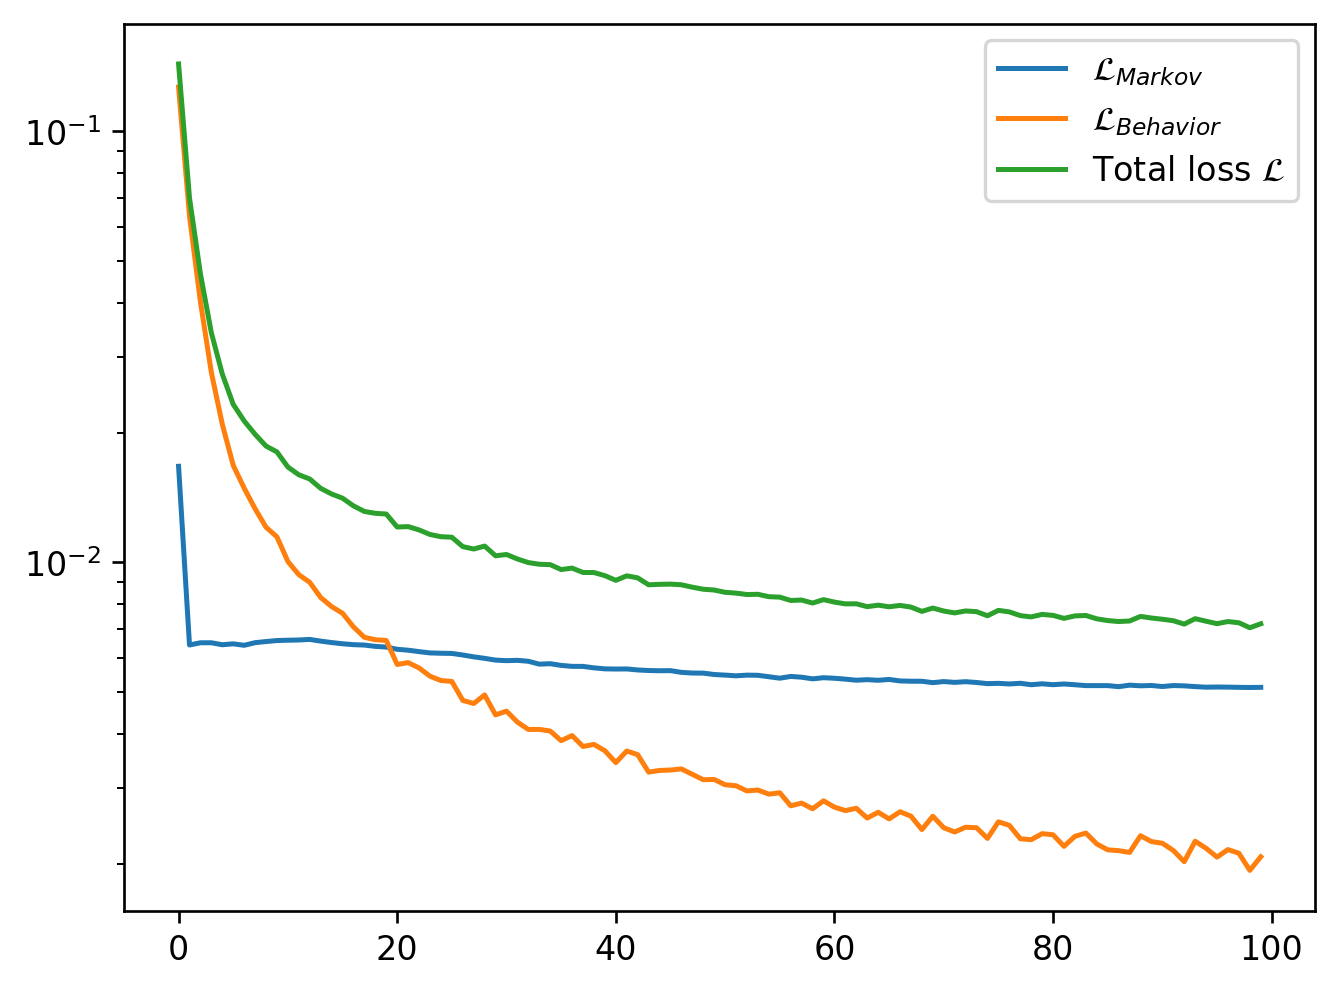

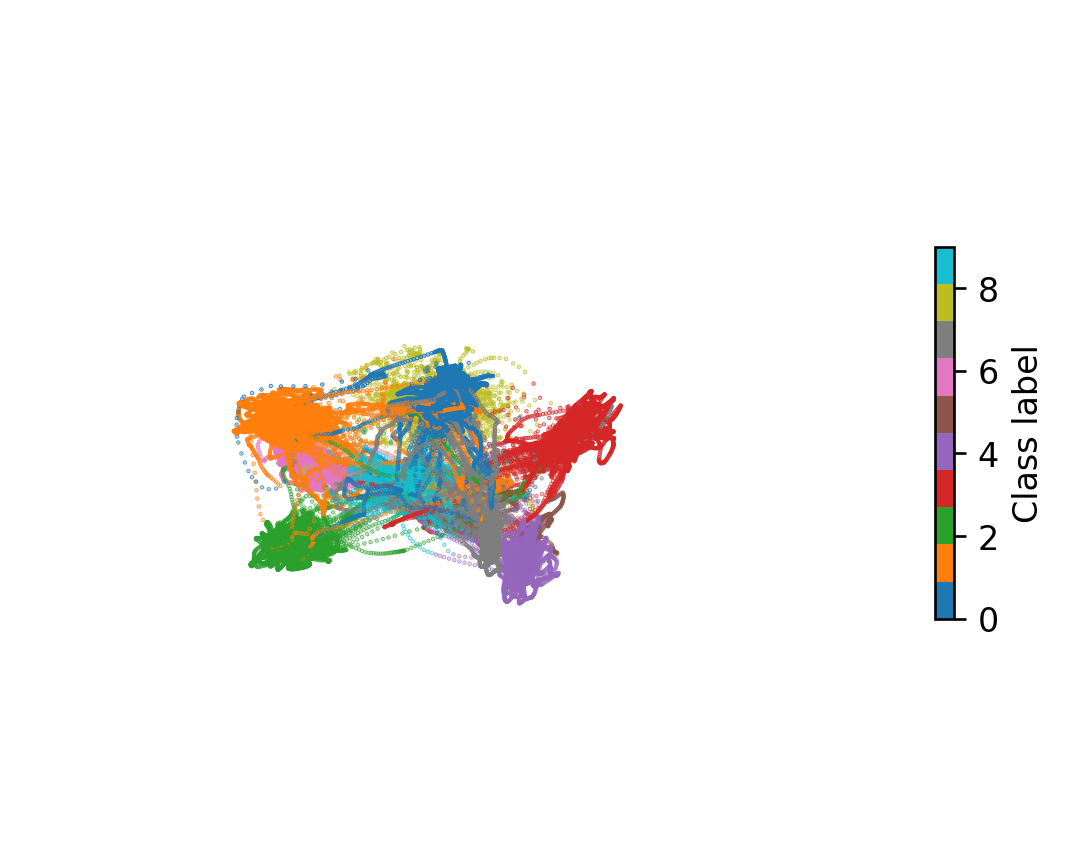

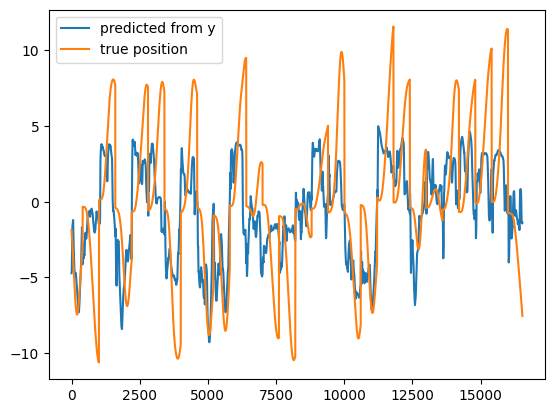

In [29]:
%matplotlib inline
plt.figure()
plt.plot(b_pred[:,0], label='predicted from y')
plt.plot(b_test[:,0], label='true position')
plt.legend()

In [31]:
import numpy as np

# Number of permutations
n_permutations = 1000
r2_permuted = []

# Run permutation test
for _ in range(n_permutations):
    shift  = np.random.randint(600,b_test.shape[0])
    b_test_shuffled = np.roll(b_test, shift) # np.random.permutation(b_test)
    r2_permuted.append(r2_score(b_test, b_test_shuffled))

# Compute p-value (one-sided test: how often chance R² ≥ observed R²)
p_value = np.mean(np.array(r2_permuted) >= r2_model)

print(f"Observed R²: {r2_model:.4f}")
print(f"Permutation p-value: {p_value:.4f}")


Observed R²: 0.2168
Permutation p-value: 0.0000


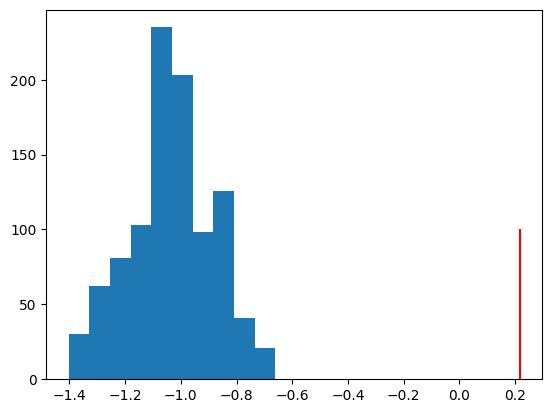

In [32]:
plt.figure()
plt.hist(r2_permuted)
plt.vlines(x=r2_model, ymax=100, ymin=0, color = 'r')
plt.show()